<a href="https://colab.research.google.com/github/MarioHervas/pytorch-tutorial/blob/main/tensor-essentials.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
torch.__version__
#Scalar structure
scalar = torch.tensor(7)
scalar.ndim
print(scalar.shape)
#Vector structure
vector = torch.tensor([7,7])
vector
vector.ndim
print(vector.shape)
#Matrix structure
MATRIX = torch.tensor([[7,8],[9,10]])
MATRIX.ndim
print(MATRIX.shape)
#Tensor structure
TENSOR = torch.tensor([[[1,2,3],[3,6,9],[2,4,5]]])
print(TENSOR)

torch.Size([])
torch.Size([2])
torch.Size([2, 2])
tensor([[[1, 2, 3],
         [3, 6, 9],
         [2, 4, 5]]])


This is the way to represent data, tensors can actually represent almost anything. The first row could be the days of the week and the rest of the rows could be sales of a certain product.

In [ ]:
print(TENSOR.ndim)
print(TENSOR.shape)

3
torch.Size([1, 3, 3])


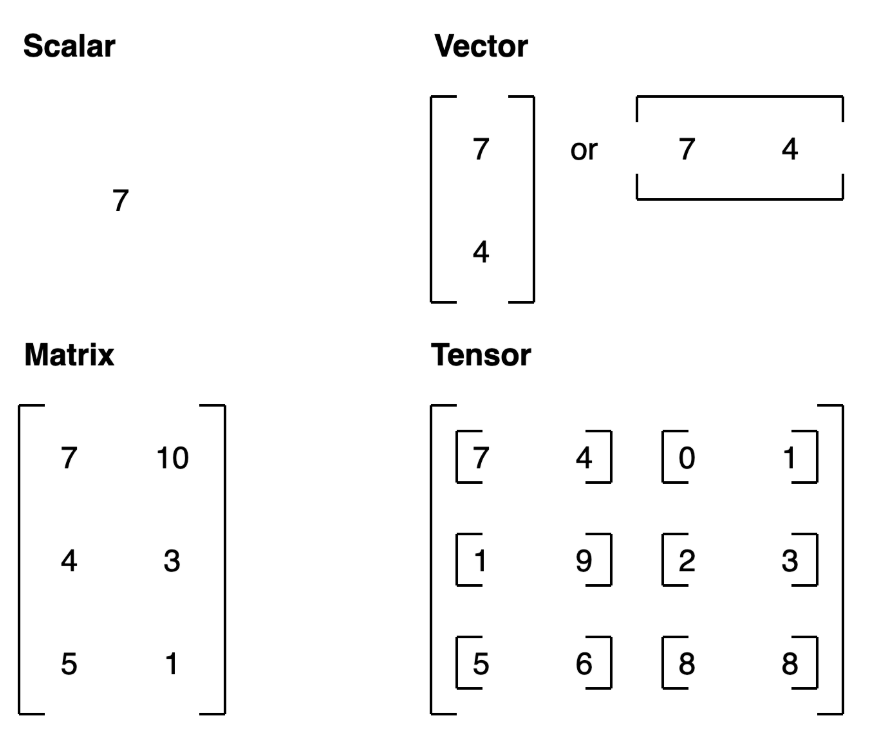

Randomness is key in ML, since we are not going to define tensors by hand. In essence:Start with random numbers -> look at data -> update random numbers -> look at data -> update random numbers...

As a data scientist, you can define how the machine learning model starts (initialization), looks at data (representation) and updates (optimization) its random numbers.

In [ ]:
random_tensor = torch.rand(size=(3,4))
random_tensor, random_tensor.dtype

#Create a random tensor of size (224,224,3)
random_image_size_tensor = torch.rand(size=(224,224,3))
random_image_size_tensor.shape, random_image_size_tensor.ndim

#Creating with ones
ones = torch.ones(size=(3,4))
ones, ones.dtype

#Range of tensors
zero_to_ten = torch.arange(start=0,end=10,step=1)
zero_to_ten

# Can also create a tensor of zeros similar to another tensor
ten_zeros = torch.zeros_like(input=zero_to_ten)
ten_zeros

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

There are several datatypes that tensors can use. Precision is the amount of detail used to describe a number, we need to put attention to this in deep leraning and numerical computing due to the large number of operations we are making.

In [ ]:
float_32_tensor = torch.tensor([3.0,6.0,9.0],dtype=None,device=None,requires_grad=False)
float_32_tensor.shape,float_32_tensor.dtype, float_32_tensor.device

float_16_tensor = torch.tensor([3.0,6.0,9.0],dtype=torch.float16)
float_16_tensor.dtype

#Obtaining basic info
some_tensor = torch.rand(3,4)
print(some_tensor)
print(f"Shape of tensor: {some_tensor.shape}")
print(f"Datatype of tensor: {some_tensor.dtype}")
print(f"Device tensor is stored on: {some_tensor.device}")

tensor([[0.5853, 0.0700, 0.2229, 0.7645],
        [0.3112, 0.0927, 0.9123, 0.9311],
        [0.6474, 0.6538, 0.9194, 0.5051]])
Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


In deep learning, data (images, text, video...) gets represented as tensors. Models learn by investigating those tensors and performing a series of operations on them to create a representation of the patterns in the input data. They are a mix of additions, substractions, multiplications, division and Matrix multiplication

In [ ]:
#Adding values to a tensor
tensor = torch.tensor([1,2,3])
tensor + 10 #All values get +10
tensor * 10 #All values get x10
#Values don't change as long as they're not reassigned
tensor = tensor - 10 #All the values get -10
tensor
tensor[0] + 20 #You can use Python indexing and slicing to handle tensors

tensor(11)

Matrix multiplication is key, we are going to use the functionality torch.matmul() but we should take into account several rules.


1.   Inner dimensions must match 2x3 * 3x2 works, but 2x3 * 2x3 won´t.
2.   Resulting Matrix will have the shape of the outer dimensions. 2x2 in previous example.

NOTE: One of the most common errors in deep learning is the mismatch of matrices sizes



In [ ]:
tensor = torch.tensor([1,2,3])
tensor.shape
print(f"Multiplicación a nivel elemento: {tensor*tensor}")
print(f"Multiplicación a nivel matriz: {tensor.matmul(tensor)}")

Multiplicación a nivel elemento: tensor([1, 4, 9])
Multiplicación a nivel matriz: 14


In [ ]:

# Importance of shape
tensor_A = torch.tensor([[1, 2],
                         [3, 4],
                         [5, 6]], dtype=torch.float32)

tensor_B = torch.tensor([[7, 10],
                         [8, 11],
                         [9, 12]], dtype=torch.float32)
#Both of these matrices are 2x3, so multiplication is not allowed. However,
# we can transform them by using other operations such as transpose.

output = tensor_A.matmul(tensor_B.T)
print(output)

tensor([[ 27.,  30.,  33.],
        [ 61.,  68.,  75.],
        [ 95., 106., 117.]])


In [ ]:
#Extracted code from learnpytorch.io

# Since the linear layer starts with a random weights matrix, let's make it reproducible (more on this later)
torch.manual_seed(42)
# This uses matrix multiplication
linear = torch.nn.Linear(in_features=2, # in_features = matches inner dimension of input
                         out_features=6) # out_features = describes outer value
x = tensor_A
print(x)
output = linear(x)
print(f"Input shape: {x.shape}\n")
print(f"Output:\n{output}\n\nOutput shape: {output.shape}")

In [ ]:
#Min, max, mean, sum
x = torch.arange(0,100,10)
print(x)
print(f"Min: {x.min()}")
print(f"Max: {x.max()}")
print(f"Mean: {x.type(torch.float32).mean()}") #Needs float datatype
print(f"Sum: {x.sum()}")
#Index of max/min values
tensor = torch.arange(10,100,10)
print(f"Tensor: {tensor}")
print(f"Index of max value: {tensor.argmax()}")
print(f"Index of min value: {tensor.argmin()}")

tensor([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])
Min: 0
Max: 90
Mean: 45.0
Sum: 450


In [ ]:
#Changing datatypes, useful for deep learning operations
tensor = torch.arange(10.,100.,10.)
tensor.dtype
tensor_float16 = tensor.type(torch.float16)
tensor_float16
tensor_int8 = tensor.type(torch.int8)
tensor_int8 #Same tensor being changed various times

tensor([10, 20, 30, 40, 50, 60, 70, 80, 90], dtype=torch.int8)

We can actaully alter the shape of tensors to be able to perform operations on them. We have reshape(), view(), stack(), squeeze(), unsqueeze(), pemute().

In [ ]:
x = torch.arange(1.,8.)
x, x.shape
x_reshaped = x.reshape(1,7)
x_reshaped, x_reshaped.shape

z = x.view(1,7) #Acts as a pointer, if you change the view you change the og

x_stacked = torch.stack([x,x,x,x],dim = 0)
print(x_stacked)

x_squeezed = x_reshaped.squeeze()
print(x_squeezed)

x_unsqueezed = x_squeezed.unsqueeze(dim=0)
print(x_unsqueezed)

tensor([[1., 2., 3., 4., 5., 6., 7.],
        [1., 2., 3., 4., 5., 6., 7.],
        [1., 2., 3., 4., 5., 6., 7.],
        [1., 2., 3., 4., 5., 6., 7.]])
tensor([1., 2., 3., 4., 5., 6., 7.])
tensor([[1., 2., 3., 4., 5., 6., 7.]])


In [ ]:
x = torch.arange(1,10).reshape(1,3,3)
x, x.shape

# Indexing Bracket by Bracket
print(f"First square bracket:\n{x[0]}")
print(f"Second square bracket: {x[0][0]}")
print(f"Third square bracket: {x[0][0][0]}")

print(x[:,:,0])

First square bracket:
tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])
Second square bracket: tensor([1, 2, 3])
Third square bracket: 1
tensor([[1, 4, 7]])


In [ ]:
import numpy as np

#Usage of NumPy in array --> tensor and backwards operation
array=np.arange(1.0,8.0)
tensor = torch.from_numpy(array)
array, tensor

(array([1., 2., 3., 4., 5., 6., 7.]),
 tensor([1., 2., 3., 4., 5., 6., 7.], dtype=torch.float64))

Randomnness takes a big part on neural networks and machine learning. The usual course of action is the following:
start with random numbers -> tensor operations -> try to make better (again and again and again). However, sometimes pure pseudorandomness isn't as helpful as using the same values over and over, sometimes we need reproducibility.

In [2]:
import torch
random_tensor_A = torch.rand(3,4)
random_tensor_B = torch.rand(3,4)

print(f"Tensor A:\n{random_tensor_A}\n")
print(f"Tensor B:\n{random_tensor_B}\n")
print(f"Does Tensor A equal Tensor B? (anywhere)")
random_tensor_A == random_tensor_B

# # Set the random seed
RANDOM_SEED=42 # try changing this to different values and see what happens to the numbers below
torch.manual_seed(seed=RANDOM_SEED)
random_tensor_C = torch.rand(3, 4)

# Have to reset the seed every time a new rand() is called
# Without this, tensor_D would be different to tensor_C
torch.random.manual_seed(seed=RANDOM_SEED) # try commenting this line out and seeing what happens
random_tensor_D = torch.rand(3, 4)

print(f"Tensor C:\n{random_tensor_C}\n")
print(f"Tensor D:\n{random_tensor_D}\n")
print(f"Does Tensor C equal Tensor D? (anywhere)")
random_tensor_C == random_tensor_D

Tensor A:
tensor([[8.3950e-01, 7.4832e-01, 2.3254e-01, 4.4128e-01],
        [5.6637e-01, 6.7669e-04, 6.2849e-01, 2.5686e-02],
        [1.6456e-01, 2.6398e-01, 2.8610e-01, 3.7200e-01]])

Tensor B:
tensor([[0.6893, 0.3395, 0.7705, 0.6293],
        [0.5249, 0.8739, 0.2108, 0.2584],
        [0.9056, 0.0834, 0.2420, 0.5044]])

Does Tensor A equal Tensor B? (anywhere)
Tensor C:
tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])

Tensor D:
tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])

Does Tensor C equal Tensor D? (anywhere)


tensor([[True, True, True, True],
        [True, True, True, True],
        [True, True, True, True]])

In [9]:
#GPU Use inside PyTorch
import torch

#Device agnostic code, since not everyplace will have GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
device

tensor = torch.tensor([1,2,3])
print(tensor,tensor.device)
tensor_on_gpu = tensor.to(device)
tensor_on_gpu

tensor_back_on_cpu = tensor_on_gpu.cpu().numpy()
tensor_back_on_cpu

tensor([1, 2, 3]) cpu


array([1, 2, 3])